In [ ]:
!pip install pandas scikit-learn shap matplotlib

In [ ]:
#data preparation
from google.colab import files
uploaded = files.upload()

Saving Deauth_18.csv to Deauth_18.csv
Saving SSH_10.csv to SSH_10.csv


In [ ]:
import pandas as pd

deauth = pd.read_csv("Deauth_18.csv")
ssh = pd.read_csv("SSH_10.csv")

print("Deauth shape:", deauth.shape)
print("SSH shape:", ssh.shape)

Deauth shape: (50000, 40)
SSH shape: (50000, 40)


In [ ]:
deauth['label'] = 1   # attack
ssh['label'] = 0      # normal

In [ ]:
df = pd.concat([deauth, ssh], ignore_index=True)

print("Combined data:", df.shape)
df.head()

Combined data: (100000, 41)


,frame.encap_type,wlan.fc.subtype,wlan.fc.frag,wlan.fc.order,wlan.fc.moredata,wlan.fc.protected,wlan.fc.pwrmgt,wlan.fc.type,wlan.fc.retry,wlan.ra,...,radiotap.rxflags,radiotap.timestamp.ts,frame.time,wlan.ta,radiotap.datarate,radiotap.mactime,wlan_radio.start_tsf,wlan_radio.end_tsf,wlan_radio.timestamp,label
0,23,11,0,0,0,0,0,1,0,00:c0:ca:a8:29:56,...,0x00000000,3409014759,Dec 18- 2020 17:49:23.440701000 GTB Standard Time,0c:9d:92:54:fe:34,12.0,1.199895e+10,1.199895e+10,1.199895e+10,1.199895e+10,1
1,23,11,0,0,0,0,0,1,0,00:c0:ca:a8:29:56,...,0x00000000,3409015298,Dec 18- 2020 17:49:23.441243000 GTB Standard Time,0c:9d:92:54:fe:34,12.0,1.199895e+10,1.199895e+10,1.199895e+10,1.199895e+10,1
2,23,11,0,0,0,0,0,1,0,00:c0:ca:a8:29:56,...,0x00000000,3409015674,Dec 18- 2020 17:49:23.441620000 GTB Standard Time,0c:9d:92:54:fe:34,12.0,1.199895e+10,1.199895e+10,1.199895e+10,1.199895e+10,1
3,23,11,0,0,0,0,0,1,0,00:c0:ca:a8:29:56,...,0x00000000,3409015889,Dec 18- 2020 17:49:23.441832000 GTB Standard Time,0c:9d:92:54:fe:34,12.0,1.199895e+10,1.199895e+10,1.199895e+10,1.199895e+10,1
4,23,11,0,0,0,0,0,1,0,00:c0:ca:a8:29:56,...,0x00000000,3409016382,Dec 18- 2020 17:49:23.442325000 GTB Standard Time,0c:9d:92:54:fe:34,12.0,1.199895e+10,1.199895e+10,1.199895e+10,1.199895e+10,1


In [ ]:
import pandas as pd

# Re-read CSVs and set labels to ensure deauth and ssh are defined
deauth = pd.read_csv("Deauth_18.csv")
ssh = pd.read_csv("SSH_10.csv")

deauth['label'] = 1   # attack
ssh['label'] = 0      # normal

df = pd.concat([deauth, ssh], ignore_index=True)
print("Re-combined data to ensure 'df' is defined:", df.shape)

Re-combined data to ensure 'df' is defined: (100000, 41)


In [ ]:
df = df.sample(frac=1).reset_index(drop=True)

In [ ]:
# Drop non-numeric features that have too many unique values
X = df.drop(['label', 'wlan.ra', 'wlan.ta', 'frame.time'], axis=1)
y = df['label']

# Now convert the remaining categorical features (like 'wlan.fc.type')
X = pd.get_dummies(X)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()
model.fit(X_train, y_train)

print("✅ Model trained")

✅ Model trained


In [ ]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)

print("🎯 Accuracy:", accuracy_score(y_test, y_pred))

🎯 Accuracy: 1.0


In [ ]:
# 1. Check if model and data exist in memory
if 'model' in globals() and 'X_test' in globals():
    # 2. Select an Attack Sample (Label 1 is Deauth)
    attack_indices = y_test[y_test == 1].index

    if len(attack_indices) > 0:
        sample = X_test.loc[[attack_indices[0]]]

        # 3. Predict
        pred = model.predict(sample)

        # 4. Display Result
        print(f"Testing Sample Index: {attack_indices[0]}")
        if pred[0] == 1:
            print("🚨 Result: Attack Detected (Deauthentication)")
        else:
            print("✅ Result: Normal Traffic (SSH)")
    else:
        print("⚠️ No attack samples found in the test set. Try re-running the split cell.")
else:
    print("❌ ERROR: Please run the training cells above first!")

Testing Sample Index: 21415
🚨 Result: Attack Detected (Deauthentication)


XAI Analysis: Why GuardAI flagged this as a Deauthentication Attack


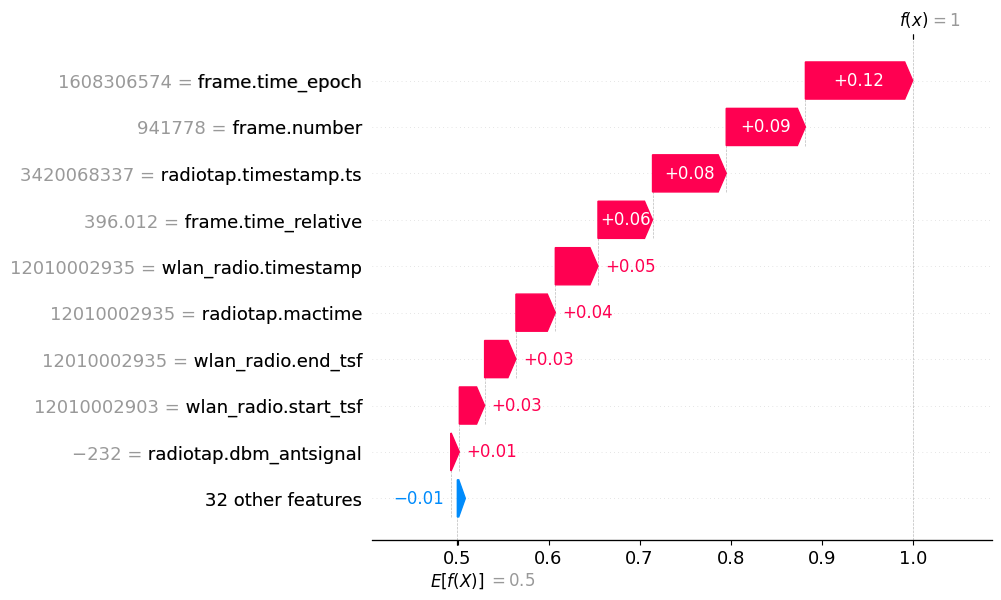

In [ ]:
import shap
import pandas as pd

# 1. Prepare numeric data for SHAP
X_test_final = X_test.apply(pd.to_numeric, errors='coerce').astype('float64').fillna(0)

# 2. Use the Attack Index (21415) found in the previous step
# We use .loc[[21415]] to get that specific Deauth sample
sample_attack = X_test_final.loc[[21415]]

# 3. Initialize the Explainer
explainer = shap.TreeExplainer(model)

# 4. Calculate SHAP values for this specific attack
# index 1 represents the "Attack" class probability
shap_values_attack = explainer(sample_attack)

# 5. The Final Step: Visualize the "Why"
print("XAI Analysis: Why GuardAI flagged this as a Deauthentication Attack")
shap.plots.waterfall(shap_values_attack[0, :, 1])

XAI Analysis: Why GuardAI flagged Index 27359 as Normal Traffic


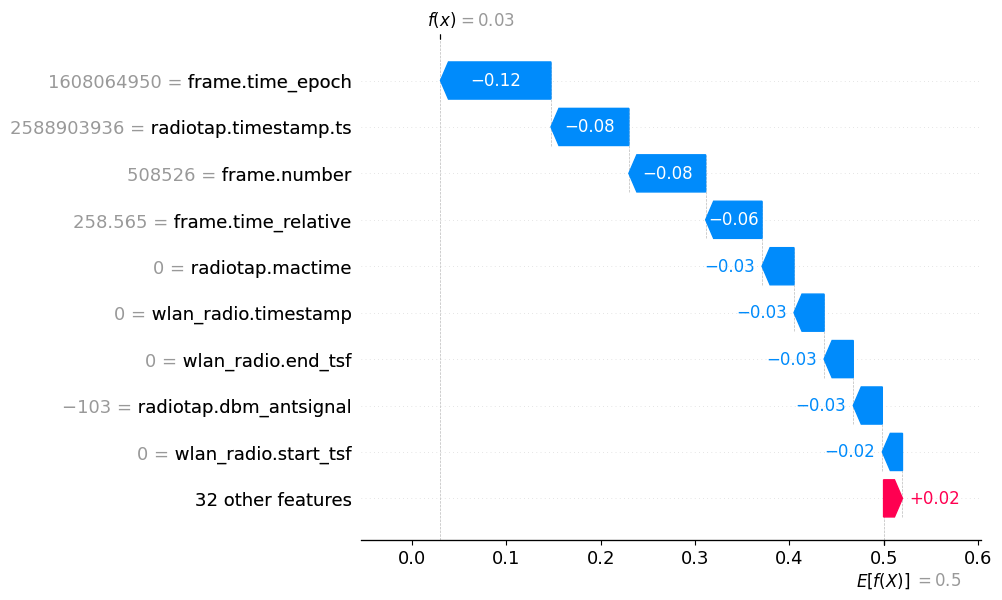

In [ ]:
# 1. Find a Normal sample (Label 0 = SSH)
normal_indices = y_test[y_test == 0].index
sample_normal = X_test_final.loc[[normal_indices[0]]]

# 2. Run SHAP for this Normal sample
shap_values_normal = explainer(sample_normal)

# 3. Visualize the "Normal" result
print(f"XAI Analysis: Why GuardAI flagged Index {normal_indices[0]} as Normal Traffic")
shap.plots.waterfall(shap_values_normal[0, :, 1])